In [1]:
from src.LM.lm_roberta_xml import (
    tokenizer, model,
    create_dataloaders, train_model, evaluate_model
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from src.data_loader import load_data
from src.preprocess import clean_text

import torch
import matplotlib.pyplot as plt
import numpy as np


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-tuning of pretrained model RoBERTa-XLM on Ecommerce text Classification Dataset

In [2]:

df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

target_names = le.classes_.tolist()

X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)


Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

Epoch 1/2, Loss: 0.2107
Epoch 2/2, Loss: 0.1260
                        precision    recall  f1-score   support

                 Books       0.98      0.96      0.97      2364
Clothing & Accessories       0.99      0.97      0.98      1734
           Electronics       0.95      0.97      0.96      2124
             Household       0.97      0.97      0.97      3863

              accuracy                           0.97     10085
             macro avg       0.97      0.97      0.97     10085
          weighted avg       0.97      0.97      0.97     10085



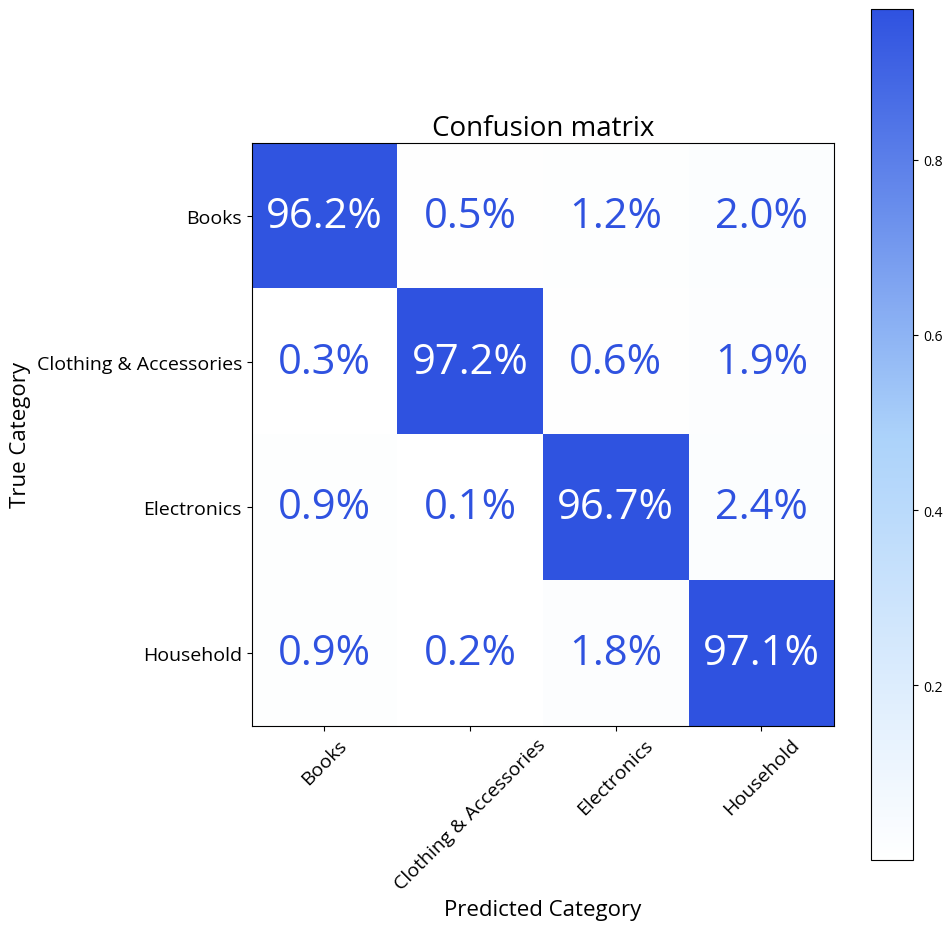

<Figure size 640x480 with 0 Axes>

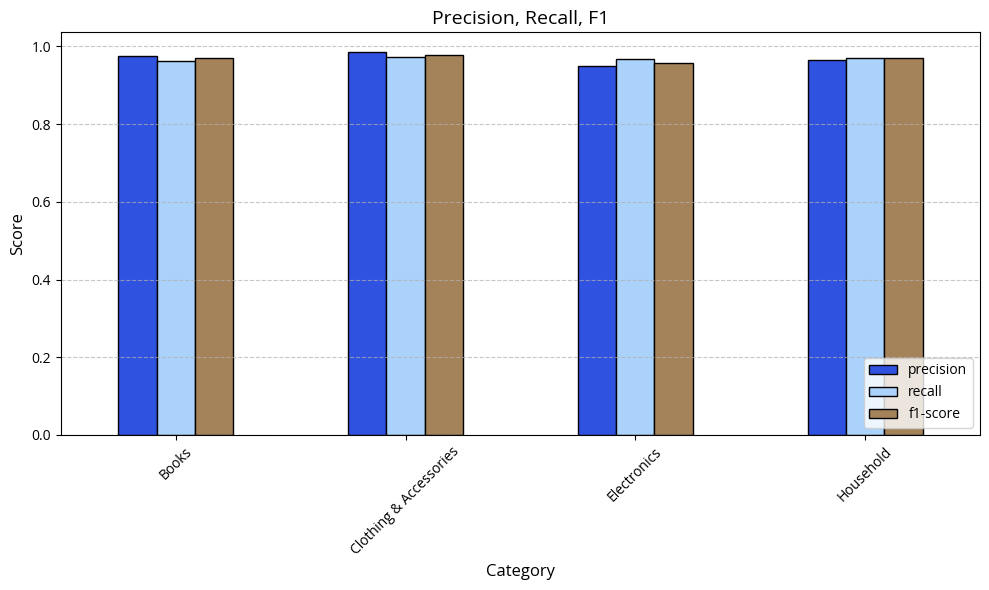

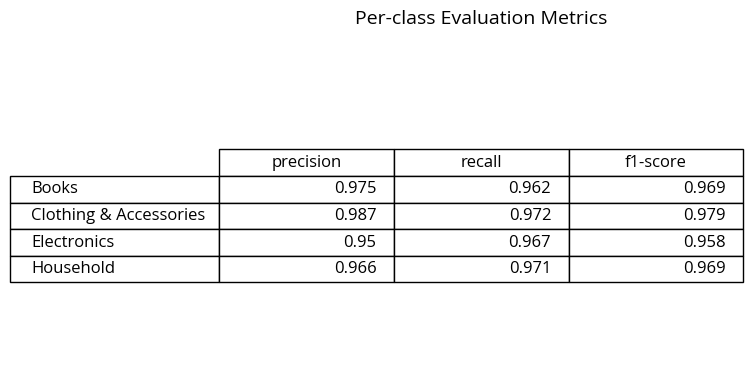

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [3]:
train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# training of model
trained_model = train_model(model, train_loader, epochs=2)
evaluate_model(trained_model, test_loader, label_names=target_names)
model.eval()

